In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt


def wave_equation():
    return sp.Eq(
        sp.Derivative(u(x, t), (t, 2)),       
        c**2 * sp.Derivative(u(x, t), (x, 2))
    )

def finite_difference(eq, u, x, t, dx, dt):
    replacements = {
        sp.Derivative(u(x, t), (t, 2)): (u(x, t + dt) - 2*u(x, t) + u(x, t - dt)) / dt**2, 
        sp.Derivative(u(x, t), (x, 2)): (u(x + dx, t) - 2*u(x, t) + u(x - dx, t)) / dx**2
    }
    return eq.xreplace(replacements)



In [ ]:
x, t, c, dx, dt = sp.symbols('x t c dx dt')
u = sp.Function('u')


eq = wave_equation()
discrete_eq = finite_difference(eq, u, x, t, dx, dt)
stencil = sp.solve(discrete_eq, u(x, t + dt))[0]
stencil = sp.simplify(stencil)
print(stencil)


Symbolic stencil: (-2*c**2*dt**2*u(x, t) + c**2*dt**2*u(-dx + x, t) + c**2*dt**2*u(dx + x, t) + dx**2*(2*u(x, t) - u(x, -dt + t)))/dx**2


In [3]:

stencil_func = sp.lambdify(
    [c, dt, dx, u(x - dx, t), u(x, t), u(x + dx, t), u(x, t - dt)], 
    stencil,
    "numpy"
)


In [4]:
# mesh
L = 3
N = 50
dx_value = L / (N - 1)
x_values = np.linspace(0, L, N)

c_value = 1.0
dt_value = 0.4 * dx_value / c_value  
T_end = 2.0
steps = int(T_end / dt_value)

r = c_value * dt_value / dx_value
print(r)


# initial conditions
u_prev = np.sin(np.pi * x_values)       
u_curr = u_prev.copy()                 
u_prev[0] = u_prev[-1] = 0.0
u_curr[0] = u_curr[-1] = 0.0



0.4


In [8]:

all_states = [u_curr.copy()]

for step in range(1, steps + 1):
    u_new = u_curr.copy()
    u_new[1:-1] = stencil_func(
        c_value, dt_value, dx_value,
        u_curr[:-2],    # u(x - dx, t)
        u_curr[1:-1],   # u(x, t)
        u_curr[2:],     # u(x + dx, t)
        u_prev[1:-1]    # u(x, t - dt) 
    )
    u_new[0] = 0.0
    u_new[-1] = 0.0
    u_prev = u_curr
    u_curr = u_new
    all_states.append(u_curr.copy())


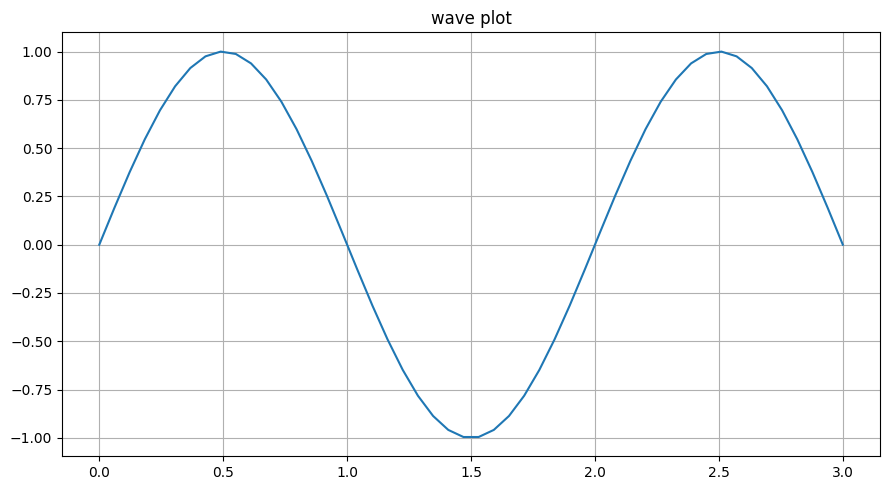

In [9]:

plt.figure(figsize=(9, 5))
for step, state in enumerate(all_states):
    if step % 100 == 0:
        plt.plot(x_values, state)

plt.title("wave plot")
plt.grid(True)
plt.tight_layout()
plt.show()